# 3 — Inverse Kinematics

Put the foot *there* · SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/03-inverse-kinematics/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** Not for training —
    MuJoCo renders video through EGL on Colab, and that needs the GPU
    runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

## Reversing last week

Last week: **angles in, foot position out.** One answer, always,
computed in twelve lines.

This week: **foot position in, angles out.** And now the question
misbehaves.

- there may be **no** solution — the target is out of reach
- there may be **many** — knee forward or knee back
- there may be **infinitely many** — more joints than constraints
- near some poses the answer exists but **explodes**

Every one of those is a real situation the Week 4 walker has to survive.

------------------------------------------------------------------------

## Nothing is falling today

Inverse kinematics is a statement about **geometry**, not balance. A
pose that solves perfectly may be one the robot cannot hold for a
moment.

So today we render **kinematics only** — poses placed and drawn, physics
never stepped. Nothing falls over, because nothing is being simulated.

Keeping that separation clear now is what lets Week 4 combine them
deliberately.

------------------------------------------------------------------------

## The easy case: two links in a plane

Ignore the hip’s roll and yaw and the ankle. What is left is a thigh and
a shin — two links, one plane — and hip, knee and foot are the corners
of a **triangle whose three sides you know**: thigh $\ell_1$, shin
$\ell_2$, and the hip-to-foot distance $d$. The law of cosines gives the
angle at any corner outright. Written for the
<span style="color:#c0392b">**knee joint angle**
${\color{#c0392b}{\theta}}$</span> — zero when the leg is straight, the
way MuJoCo’s knee counts — the triangle’s interior corner is
$\pi - {\color{#c0392b}{\theta}}$, and the
<span style="color:#2e8b57">hip corner
${\color{#2e8b57}{\varphi}}$</span> comes the same way:

$$\cos{\color{#c0392b}{\theta_{\text{knee}}}} = \frac{d^2 - \ell_1^2 - \ell_2^2}{2\,\ell_1\ell_2},
\qquad
\cos{\color{#2e8b57}{\varphi}} = \frac{\ell_1^2 + d^2 - \ell_2^2}{2\,\ell_1 d}$$

In [1]:
try:
    import soc4180
except ImportError:
    %pip install -q "soc4180 @ git+https://github.com/gnoejh/soc4180.git"
    import soc4180

import numpy as np
import mujoco
from soc4180 import kinematics as kin

model = soc4180.load_g1()
data = soc4180.keyframe_data(model, "stand")
mujoco.mj_forward(model, data)

def anchor(body_name):
    """World position of a body's joint axis — where the link actually pivots."""
    b = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, body_name)
    j = model.body_jntadr[b]
    return data.xpos[b] + data.xmat[b].reshape(3, 3) @ model.jnt_pos[j]

thigh = np.linalg.norm(anchor("left_knee_link") - anchor("left_hip_pitch_link"))
shin = np.linalg.norm(anchor("left_ankle_pitch_link") - anchor("left_knee_link"))
print(f"thigh  l1 = {thigh:.4f} m")
print(f"shin   l2 = {shin:.4f} m")
print(f"reach is an annulus: {abs(thigh-shin):.4f} m to {thigh+shin:.4f} m")

thigh  l1 = 0.3409 m
shin   l2 = 0.3000 m
reach is an annulus: 0.0409 m to 0.6409 m

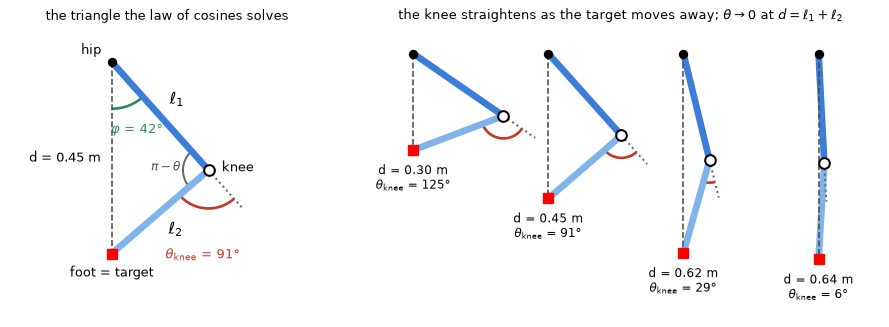

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def planar_leg(d, l1=thigh, l2=shin):
    """Hip at the origin, foot straight below it, knee forward: corners and angles."""
    phi = np.arccos((l1**2 + d**2 - l2**2) / (2 * l1 * d))        # corner at the hip
    theta = np.arccos((d**2 - l1**2 - l2**2) / (2 * l1 * l2))     # knee joint angle, 0 = straight
    knee = np.array([l1 * np.sin(phi), -l1 * np.cos(phi)])
    return phi, theta, knee, np.array([0.0, -d])

def draw_leg(ax, d, x0=0.0, arc_r=0.08):
    """Thigh, shin, the dashed hip-to-foot side, and the knee joint angle: how far
    the shin turns away from the thigh's own line (dotted)."""
    phi, theta, knee, foot = planar_leg(d)
    knee, foot = knee + [x0, 0], foot + [x0, 0]
    ax.plot([x0, knee[0]], [0, knee[1]], lw=5, color="#3b7dd8", solid_capstyle="round")
    ax.plot([knee[0], foot[0]], [knee[1], foot[1]], lw=5, color="#7fb3ea", solid_capstyle="round")
    ax.plot([x0, foot[0]], [0, foot[1]], "--", lw=1.2, color="0.3")
    ext = knee + 0.12 * np.array([np.sin(phi), -np.cos(phi)])       # thigh, continued past the knee
    ax.plot([knee[0], ext[0]], [knee[1], ext[1]], ":", color="0.4")
    ax.plot(x0, 0, "ko", ms=6, zorder=4)
    ax.plot(*knee, "o", ms=8, color="w", mec="k", mew=1.5, zorder=4)
    ax.plot(*foot, "rs", ms=8, zorder=4)
    a_hip = np.degrees(np.arctan2(-knee[1], x0 - knee[0]))          # direction knee -> hip
    a_foot = a_hip + 180 - np.degrees(theta)                        # direction knee -> foot
    ax.add_patch(Arc(knee, 2 * arc_r, 2 * arc_r, theta1=a_foot,     # shin -> thigh's line
                     theta2=a_hip + 180, color="#c0392b", lw=2))
    return phi, theta, knee, foot, a_hip, a_foot

deg = np.degrees
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.6, 3.4), gridspec_kw={"width_ratios": [1, 1.6]})

# left: one triangle with every side and corner named
d0 = 0.45
phi, theta, knee, foot, a_hip, a_foot = draw_leg(ax0, d0, arc_r=0.09)
mid = np.radians((a_foot + a_hip + 180) / 2)
ax0.text(knee[0] + 0.2 * np.cos(mid), knee[1] + 0.2 * np.sin(mid),
         r"$\theta_{\rm knee}$" + f" = {deg(theta):.0f}°", color="#c0392b", ha="center", va="center")
ax0.add_patch(Arc(knee, 0.12, 0.12, theta1=a_hip, theta2=a_foot, color="0.4", lw=1.5))
mid = np.radians((a_hip + a_foot) / 2)
ax0.text(knee[0] + 0.1 * np.cos(mid), knee[1] + 0.1 * np.sin(mid), r"$\pi - \theta$",
         color="0.3", ha="center", va="center", fontsize=9)
ax0.add_patch(Arc((0, 0), 0.22, 0.22, theta1=270, theta2=270 + deg(phi), color="#2e8b57", lw=2))
mid = np.radians(270 + deg(phi) / 2)
ax0.text(0.17 * np.cos(mid), 0.17 * np.sin(mid), r"$\varphi$" + f" = {deg(phi):.0f}°",
         color="#2e8b57", ha="center", va="center")
ax0.text(*(knee / 2 + 0.03 * np.array([np.cos(phi), np.sin(phi)])), r"$\ell_1$",
         ha="left", va="bottom", fontsize=12)
sh = foot - knee; n = np.array([-sh[1], sh[0]]) / np.linalg.norm(sh)  # outward normal of the shin
ax0.text(*((knee + foot) / 2 + 0.03 * n), r"$\ell_2$", ha="left", va="top", fontsize=12)
ax0.text(-0.025, -d0 / 2, f"d = {d0:.2f} m", ha="right", va="center", fontsize=10)
ax0.annotate("hip", (0, 0), xytext=(-8, 6), textcoords="offset points", ha="right")
ax0.annotate("knee", knee, xytext=(10, 2), textcoords="offset points", va="center")
ax0.annotate("foot = target", foot, xytext=(0, -9), textcoords="offset points", ha="center", va="top")
ax0.set_aspect("equal"); ax0.set_xlim(-0.24, 0.5); ax0.set_ylim(-0.6, 0.08); ax0.set_axis_off()
ax0.set_title("the triangle the law of cosines solves", fontsize=10)

# right: the same triangle for four distances, out to the straight leg
for k, dk in enumerate((0.30, 0.45, 0.62, thigh + shin - 1e-3)):
    x0 = 0.42 * k
    _, th, _, ft, _, _ = draw_leg(ax1, dk, x0=x0, arc_r=0.07)
    ax1.text(x0, ft[1] - 0.04, f"d = {dk:.2f} m\n" + r"$\theta_{\rm knee}$" + f" = {deg(th):.0f}°",
             ha="center", va="top", fontsize=9)
ax1.set_aspect("equal"); ax1.set_xlim(-0.16, 1.45); ax1.set_ylim(-0.82, 0.08); ax1.set_axis_off()
ax1.set_title(r"the knee straightens as the target moves away; $\theta \to 0$ at $d = \ell_1 + \ell_2$",
              fontsize=10)
fig.tight_layout(); plt.show()

------------------------------------------------------------------------

## What the closed form tells you

In [3]:
def knee_angle(d, l1=thigh, l2=shin):
    """Knee joint angle (0 = straight leg) for a hip-to-foot distance d, or None if unreachable."""
    c = (d**2 - l1**2 - l2**2) / (2 * l1 * l2)
    if abs(c) > 1.0:
        return None                      # outside the annulus: no solution
    return np.arccos(c)

for dist in (0.02, 0.20, 0.40, 0.60, 0.64, 0.70):
    a = knee_angle(dist)
    print(f"  d={dist:.2f} m -> " +
          ("unreachable" if a is None else f"knee angle {np.degrees(a):6.1f} deg"))

  d=0.02 m -> unreachable
  d=0.20 m -> knee angle  144.4 deg
  d=0.40 m -> knee angle  103.1 deg
  d=0.60 m -> knee angle   41.3 deg
  d=0.64 m -> knee angle    6.2 deg
  d=0.70 m -> unreachable

Three lessons in one table:

- Reachable distances form an **annulus**, not a disc — too close is as
  impossible as too far
- $\arccos$ returns one angle, but $-\theta$ works equally well: **two
  solutions**, knee-forward and knee-back. Humans use one of them; the
  mathematics does not care
- As $d$ approaches $\ell_1+\ell_2$ the knee straightens, and the
  sensitivity of angle to distance **diverges**

------------------------------------------------------------------------

## Seen, not read

Differentiate the law of cosines and the sensitivity of angle to
distance falls out with $\sin\theta$ in the denominator:

$${\color{#c0392b}{\left|\frac{d\theta}{d\,d}\right|}} = \frac{d}{\ell_1\,\ell_2\,\sin{\color{#3b7dd8}{\theta}}}$$

At full reach ${\color{#3b7dd8}{\theta}} \to 0$,
$\sin{\color{#3b7dd8}{\theta}} \to 0$, and one millimetre of target asks
for whole degrees of knee: <span style="color:#3b7dd8">blue is the
angle</span>, <span style="color:#c0392b">red its derivative</span>.

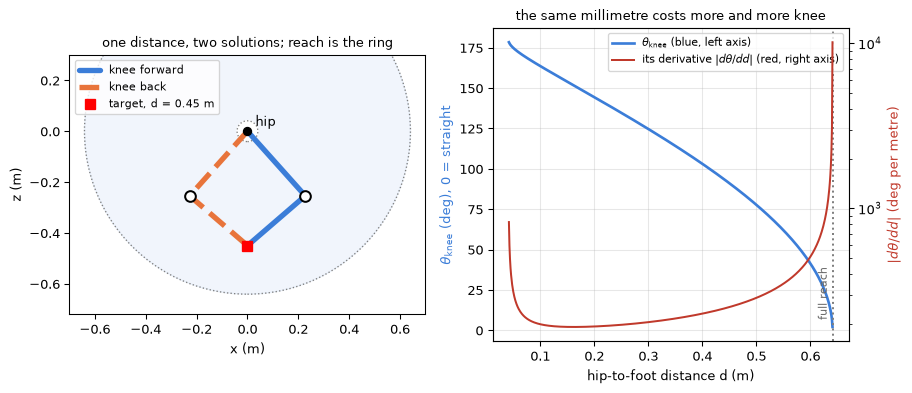

In [4]:
import matplotlib.pyplot as plt

d = np.linspace(abs(thigh - shin) + 1e-3, thigh + shin - 1e-4, 600)
c = (d**2 - thigh**2 - shin**2) / (2 * thigh * shin)
bend = np.arccos(c)                               # knee joint angle: 0 is a straight leg
sens = d / (thigh * shin * np.sqrt(1 - c**2))     # |d theta / d d|

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.6, 4.2))

# left: one target distance, both solutions, drawn inside the reachable ring
d_show = 0.45
phi = np.arccos((thigh**2 + d_show**2 - shin**2) / (2 * thigh * d_show))   # hip angle
ax0.add_patch(plt.Circle((0, 0), thigh + shin, color="#3b7dd8", alpha=0.07, zorder=0))
ax0.add_patch(plt.Circle((0, 0), abs(thigh - shin), color="w", zorder=1))
for r in (thigh + shin, abs(thigh - shin)):
    ax0.add_patch(plt.Circle((0, 0), r, fill=False, ls=":", color="0.5", zorder=1))
for sgn, style, col, label in ((+1, "-", "#3b7dd8", "knee forward"),
                               (-1, "--", "#e8743b", "knee back")):
    kx, kz = sgn * thigh * np.sin(phi), -thigh * np.cos(phi)
    ax0.plot([0, kx, 0], [0, kz, -d_show], style, lw=4, color=col,
             solid_capstyle="round", label=label, zorder=3)
    ax0.plot(kx, kz, "o", ms=8, color="w", mec="k", mew=1.5, zorder=4)
ax0.plot(0, 0, "ko", ms=6, zorder=4)
ax0.plot(0, -d_show, "rs", ms=8, label=f"target, d = {d_show} m", zorder=4)
ax0.annotate("hip", (0, 0), xytext=(6, 4), textcoords="offset points")
ax0.set_aspect("equal"); ax0.set_xlim(-0.7, 0.7); ax0.set_ylim(-0.72, 0.3)
ax0.set_xlabel("x (m)"); ax0.set_ylabel("z (m)")
ax0.legend(fontsize=8, loc="upper left")
ax0.set_title("one distance, two solutions; reach is the ring", fontsize=10)

# right: knee angle and its sensitivity against distance
l_theta, = ax1.plot(d, np.degrees(bend), lw=2, color="#3b7dd8", label=r"$\theta_{\rm knee}$ (blue, left axis)")
ax1.set_xlabel("hip-to-foot distance d (m)")
ax1.set_ylabel(r"$\theta_{\rm knee}$ (deg), 0 = straight", color="#3b7dd8")
ax1.axvline(thigh + shin, color="0.5", ls=":")
ax1.text(thigh + shin - 0.006, 8, "full reach", rotation=90, fontsize=8, color="0.4", ha="right")
ax2 = ax1.twinx()
l_sens, = ax2.semilogy(d, np.degrees(sens), lw=1.5, color="#c0392b",
                       label=r"its derivative $|d\theta/dd|$ (red, right axis)")
ax2.set_ylabel(r"$|d\theta/dd|$ (deg per metre)", color="#c0392b")
ax1.legend(handles=[l_theta, l_sens], fontsize=8, loc="upper right")
ax1.set_title("the same millimetre costs more and more knee", fontsize=10)
ax1.grid(alpha=0.3)
fig.tight_layout(); plt.show()

------------------------------------------------------------------------

## Why we cannot stop there

The closed form handles two joints in a plane. A real foot pose is **six
numbers** — three position, three orientation — and the leg has six
joints.

Deriving closed-form IK for all six is possible, and it is:

- specific to this exact robot, and wrong for any other
- painful to extend when a joint limit or an obstacle intrudes
- brittle: a small model change invalidates the derivation

So we use a method that needs no derivation at all, works for any chain,
and degrades gracefully when the problem is ill-posed.

------------------------------------------------------------------------

## Differential IK

**Forward kinematics, in velocities** (last week’s Jacobian). Colour
code for the rest of the week: <span style="color:#3b7dd8">**blue** is
joint motion</span>, <span style="color:#c0392b">**red** is foot
motion</span>, $J$ is the map between them:

$${\color{#c0392b}{\dot{\mathbf{x}}}} = J(q)\,{\color{#3b7dd8}{\dot{q}}}$$

- ${\color{#3b7dd8}{q}}$ — the vector of joint angles;
  ${\color{#3b7dd8}{\dot{q}}}$ — how fast each joint is turning
- ${\color{#c0392b}{\mathbf{x}}}$ — the foot (end-effector) position and
  orientation; ${\color{#c0392b}{\dot{\mathbf{x}}}}$ — how fast the foot
  moves
- $J(q)$ — the Jacobian: the matrix that turns
  <span style="color:#3b7dd8">joint speeds</span> into
  <span style="color:#c0392b">foot speed</span>, and changes with the
  pose

*If you know <span style="color:#3b7dd8">how fast the joints
move</span>, the Jacobian tells you <span style="color:#c0392b">how fast
the foot moves</span>.*

**Inverse kinematics asks the opposite:** *what
<span style="color:#3b7dd8">joint motion</span> produces the
<span style="color:#c0392b">foot motion</span> I want?* So do not solve
for the angles. Solve for a small **change** in the angles that moves
the foot toward the target, then repeat. Rearranged:

$$J\,{\color{#3b7dd8}{\Delta q}} = {\color{#c0392b}{\mathbf{e}}}$$

- ${\color{#c0392b}{\mathbf{e}}}$ — the desired foot motion: a small
  step toward the target
- ${\color{#3b7dd8}{\Delta q}}$ — the joint-angle change that produces
  that motion

------------------------------------------------------------------------

## The obvious answer: ${\color{#3b7dd8}{\Delta q}} = J^{-1}{\color{#c0392b}{\mathbf{e}}}$

Six equations, six unknowns: for one leg $J$ is $6 \times 6$, so if it
is invertible the system
$J\,{\color{#3b7dd8}{\Delta q}} = {\color{#c0392b}{\mathbf{e}}}$ has
exactly one solution,

$${\color{#3b7dd8}{\Delta q}} = J^{-1}\,{\color{#c0392b}{\mathbf{e}}}.$$

$J$ maps <span style="color:#3b7dd8">joint motion</span> to
<span style="color:#c0392b">foot motion</span>; $J^{-1}$ runs that map
backwards. Hand it <span style="color:#c0392b">the foot motion you
want</span> and it returns <span style="color:#3b7dd8">the joint motion
that produces it</span> — exactly, so that
$J\,{\color{#3b7dd8}{\Delta q}} = {\color{#c0392b}{\mathbf{e}}}$ holds
to machine precision.

What the inverse *costs* shows in the singular value decomposition. With
$J = U\Sigma V^{\mathsf T}$, $J^{-1} = V\Sigma^{-1}U^{\mathsf T}$: each
direction the foot can move is **divided by its own
${\color{#e8743b}{\sigma_i}}$**. A direction the leg barely moves (small
${\color{#e8743b}{\sigma_i}}$) needs $1/{\color{#e8743b}{\sigma_i}}$ of
joint motion; at a singularity ${\color{#e8743b}{\sigma_i}} = 0$ and no
solution exists — and just beside it, a huge one.

In [5]:
jac_p, jac_r = np.zeros((3, model.nv)), np.zeros((3, model.nv))
mujoco.mj_jacSite(model, data, jac_p, jac_r, kin.foot_site_id(model, "left"))
J = np.vstack([jac_p, jac_r])[:, kin.leg_dof_indices(model, "left")]   # at stand

crouch = soc4180.WalkingController(model).nominal        # the week 4 crouch
bent = mujoco.MjData(model); bent.qpos[:] = crouch; mujoco.mj_forward(model, bent)
mujoco.mj_jacSite(model, bent, jac_p, jac_r, kin.foot_site_id(model, "left"))
J_crouch = np.vstack([jac_p, jac_r])[:, kin.leg_dof_indices(model, "left")]

err = np.array([0.0, 0.0, -0.05, 0, 0, 0])       # ask to lower the foot 5 cm
for name, Jp in (("crouch", J_crouch), ("stand", J)):
    dq = np.linalg.solve(Jp, err)                # dq = J^{-1} e, no damping
    sigma_min = np.linalg.svd(Jp, compute_uv=False).min()
    print(f"  {name:7} sigma_min = {sigma_min:.1e}   |dq| = {np.linalg.norm(dq):10.4g} rad"
          f"   |J dq - e| = {np.linalg.norm(Jp @ dq - err):.0e}")

  crouch  sigma_min = 8.9e-02   |dq| =     0.5632 rad   |J dq - e| = 1e-17
  stand   sigma_min = 9.0e-07   |dq| =  5.578e+04 rad   |J dq - e| = 3e-13

Crouched, the inverse is a fine answer: half a radian, shared by hip,
knee and ankle. Standing — the straight leg,
$\sigma_{\min} \approx 10^{-6}$ — the same 5 cm request costs **tens of
thousands of radians**, and the residual is still zero: the algebra
*succeeded* and commanded the impossible. That is what the next slide
damps.

------------------------------------------------------------------------

## Damped least squares

Instead of demanding an exact solution, ask for a compromise:
<span style="color:#c0392b">reduce the error</span> *and*
<span style="color:#3b7dd8">keep the joint motion small</span>. One new
number, <span style="color:#e8743b">the damping
${\color{#e8743b}{\lambda}}$</span>, sets the trade:

$${\color{#3b7dd8}{\Delta q}} = J^{\mathsf{T}}\left(J J^{\mathsf{T}} + {\color{#e8743b}{\lambda^2}} I\right)^{-1}{\color{#c0392b}{\mathbf{e}}}$$

${\color{#e8743b}{\lambda}}$ trades accuracy against stability. Away
from singularities it barely matters; near one it is the difference
between a smooth motion and a violent lunge.

In [6]:
for lam in (0.0, 1e-3, 1e-2, 1e-1):                 # same J at stand, same 5 cm request
    M = J @ J.T + lam**2 * np.eye(6)
    dq = J.T @ np.linalg.solve(M, err)
    print(f"  lambda={lam:<6}  |dq| = {np.linalg.norm(dq):10.2f} rad")

  lambda=0.0     |dq| =   55778.24 rad
  lambda=0.001   |dq| =       0.04 rad
  lambda=0.01    |dq| =       0.00 rad
  lambda=0.1     |dq| =       0.00 rad

------------------------------------------------------------------------

## Where the formula comes from: the cost

Instead of *solving*
$J\,{\color{#3b7dd8}{\Delta q}} = {\color{#c0392b}{\mathbf{e}}}$, ask
for the ${\color{#3b7dd8}{\Delta q}}$ that **minimises a cost** with two
terms — <span style="color:#c0392b">the error left over</span>, and
<span style="color:#e8743b">the joint motion spent</span>:

$$C({\color{#3b7dd8}{\Delta q}}) = {\color{#c0392b}{\|J\,\Delta q - \mathbf{e}\|^2}} + {\color{#e8743b}{\lambda^2\,\|\Delta q\|^2}} .$$

**Step 1 — expand.** Using $\|v\|^2 = v^{\mathsf T}v$:

$$C = {\color{#c0392b}{\Delta q^{\mathsf T} J^{\mathsf T} J\,\Delta q \;-\; 2\,\mathbf{e}^{\mathsf T} J\,\Delta q \;+\; \mathbf{e}^{\mathsf T}\mathbf{e}}}
    \;+\; {\color{#e8743b}{\lambda^2\,\Delta q^{\mathsf T}\Delta q}} .$$

**Step 2 — differentiate with respect to ${\color{#3b7dd8}{\Delta q}}$**
(for a symmetric $A$, $\nabla\, v^{\mathsf T} A v = 2Av$ and
$\nabla\, b^{\mathsf T} v = b$):

$$\nabla C = {\color{#c0392b}{2\,J^{\mathsf T} J\,\Delta q \;-\; 2\,J^{\mathsf T}\mathbf{e}}} \;+\; {\color{#e8743b}{2\lambda^2\,\Delta q}} .$$

**Step 3 — set it to zero.** The minimum satisfies the *normal
equations*

$$\left(J^{\mathsf T} J + {\color{#e8743b}{\lambda^2}} I\right){\color{#3b7dd8}{\Delta q}} = J^{\mathsf T}{\color{#c0392b}{\mathbf{e}}}
\qquad\Longrightarrow\qquad
{\color{#3b7dd8}{\Delta q}} = \left(J^{\mathsf T} J + {\color{#e8743b}{\lambda^2}} I\right)^{-1} J^{\mathsf T}{\color{#c0392b}{\mathbf{e}}}.$$

It *is* the minimum, not just a stationary point: the Hessian
$2(J^{\mathsf T}J +
{\color{#e8743b}{\lambda^2}} I)$ is positive definite for any
${\color{#e8743b}{\lambda}} > 0$, because
$v^{\mathsf T}J^{\mathsf T}Jv = \|Jv\|^2 \ge 0$ and
${\color{#e8743b}{\lambda^2}}\|v\|^2 > 0$. The same fact says the
inverse **always exists** — even at a singularity, where $J^{-1}$ does
not. That is the whole point of <span style="color:#e8743b">the second
term</span>.

------------------------------------------------------------------------

## Where the formula comes from: two forms

The previous slide wrote
$\Delta q = J^{\mathsf T}(J J^{\mathsf T} + \lambda^2 I)^{-1}\mathbf{e}$
— the transpose on the *outside*. Both are the same vector, by the
*push-through identity*. Start from a product that can be read two ways:

$$J^{\mathsf T}\left(J J^{\mathsf T} + \lambda^2 I\right)
 \;=\; J^{\mathsf T} J J^{\mathsf T} + \lambda^2 J^{\mathsf T}
 \;=\; \left(J^{\mathsf T} J + \lambda^2 I\right) J^{\mathsf T}.$$

Multiply on the left by $(J^{\mathsf T}J + \lambda^2 I)^{-1}$ and on the
right by $(JJ^{\mathsf T} + \lambda^2 I)^{-1}$:

$$\left(J^{\mathsf T} J + \lambda^2 I\right)^{-1} J^{\mathsf T}
 \;=\; J^{\mathsf T}\left(J J^{\mathsf T} + \lambda^2 I\right)^{-1}.$$

Why keep both? For a $6 \times n$ Jacobian the left form inverts an
$n \times n$ matrix and the right form a $6 \times 6$ one; with more
joints than constraints the right form is the cheaper solve. For the
leg, $n = 6$, and they cost the same.

------------------------------------------------------------------------

## Where the formula comes from: each direction

**What the update does to each direction.** Write
$J = U\,\Sigma\,V^{\mathsf T}$. Then
$J^{\mathsf T}J + \lambda^2 I = V(\Sigma^2 + \lambda^2 I)V^{\mathsf T}$
and $J^{\mathsf T}\mathbf{e} = V\,\Sigma\,U^{\mathsf T}\mathbf{e}$, so

$${\color{#3b7dd8}{\Delta q}} = V\,\underbrace{(\Sigma^2 + {\color{#e8743b}{\lambda^2}} I)^{-1}\Sigma}_{\text{diagonal}}\;U^{\mathsf T}{\color{#c0392b}{\mathbf{e}}}$$

so direction $i$ is scaled by

$$\frac{\sigma_i}{\sigma_i^2 + {\color{#e8743b}{\lambda^2}}}
\approx \begin{cases} {\color{#2e8b57}{1/\sigma_i}} & \sigma_i \gg {\color{#e8743b}{\lambda}} \quad{\color{#2e8b57}{\text{the true inverse}}}\\[2pt]
{\color{#c0392b}{\sigma_i/\lambda^2 \to 0}} & \sigma_i \ll {\color{#e8743b}{\lambda}} \quad{\color{#c0392b}{\text{switched off}}}\end{cases}$$

${\color{#e8743b}{\lambda}}$ is a **threshold**: directions the Jacobian
barely moves are <span style="color:#c0392b">ignored</span> rather than
amplified; the others get <span style="color:#2e8b57">the true
inverse</span>. That is the whole trick.

In [7]:
lam = 1e-3
I6 = np.eye(6)
dq_left = np.linalg.solve(J.T @ J + lam**2 * I6, J.T @ err)     # (J'J + l2 I)^-1 J' e
dq_right = J.T @ np.linalg.solve(J @ J.T + lam**2 * I6, err)    # J' (J J' + l2 I)^-1 e
U, sig, Vt = np.linalg.svd(J)
dq_svd = Vt.T @ ((sig / (sig**2 + lam**2)) * (U.T @ err))       # V diag(.) U' e
print(f"  left form vs right form : {np.abs(dq_left - dq_right).max():.1e}")
print(f"  either form vs SVD form : {np.abs(dq_left - dq_svd).max():.1e}")
print("  per-direction gain sigma/(sigma^2+lambda^2) vs the inverse's 1/sigma, at stand:")
for s_i in sig:
    print(f"    sigma = {s_i:8.2e}   damped {s_i/(s_i**2+lam**2):10.3g}   inverse {1/s_i:10.3g}")

  left form vs right form : 5.0e-12
  either form vs SVD form : 5.0e-12
  per-direction gain sigma/(sigma^2+lambda^2) vs the inverse's 1/sigma, at stand:
    sigma = 1.83e+00   damped      0.547   inverse      0.547
    sigma = 1.49e+00   damped      0.672   inverse      0.672
    sigma = 1.00e+00   damped          1   inverse          1
    sigma = 4.26e-01   damped       2.35   inverse       2.35
    sigma = 4.22e-01   damped       2.37   inverse       2.37
    sigma = 8.96e-07   damped      0.896   inverse   1.12e+06

------------------------------------------------------------------------

## The same sweep, from both poses

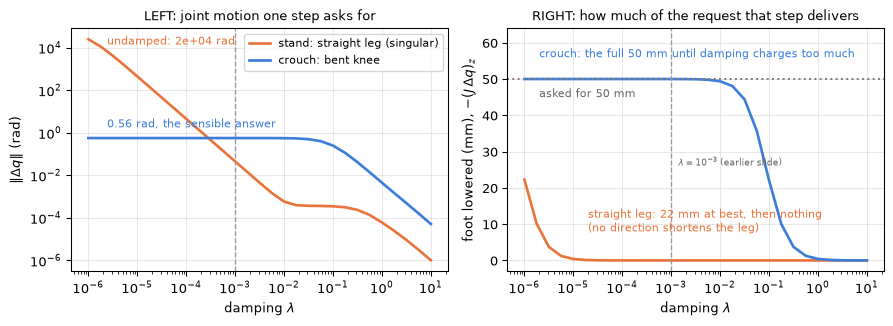

In [8]:
lams = np.logspace(-6, 1, 29)                     # damping, almost-inverse to heavy
sweep = {}
for Jp, name in ((J, "stand"), (J_crouch, "crouch")):
    size, drop = [], []
    for lam in lams:
        dq = Jp.T @ np.linalg.solve(Jp @ Jp.T + lam**2 * np.eye(6), err)
        size.append(np.linalg.norm(dq)); drop.append(-(Jp @ dq)[2] * 1000)
    sweep[name] = (np.array(size), np.array(drop))

cols = {"stand": "#e8743b", "crouch": "#3b7dd8"}
names = {"stand": "stand: straight leg (singular)", "crouch": "crouch: bent knee"}
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.6, 3.5))
for k in ("stand", "crouch"):
    size, drop = sweep[k]
    ax0.loglog(lams, size, lw=2, color=cols[k], label=names[k])
    ax1.semilogx(lams, drop, lw=2, color=cols[k], label=names[k])

# LEFT: the size of the joint step the solver asks for
ax0.set_title("LEFT: joint motion one step asks for", fontsize=10)
ax0.set_xlabel(r"damping $\lambda$"); ax0.set_ylabel(r"$\|\Delta q\|$ (rad)")
ax0.annotate(f"undamped: {sweep['stand'][0][0]:.0e} rad", (lams[0], sweep['stand'][0][0]),
             xytext=(14, -4), textcoords="offset points", fontsize=8, color=cols["stand"])
ax0.annotate(f"{sweep['crouch'][0][0]:.2f} rad, the sensible answer", (lams[0], sweep['crouch'][0][0]),
             xytext=(14, 8), textcoords="offset points", fontsize=8, color=cols["crouch"])
ax0.legend(fontsize=8, loc="upper right")

# RIGHT: how far that step really moves the foot (first order, J dq)
ax1.set_title("RIGHT: how much of the request that step delivers", fontsize=10)
ax1.set_xlabel(r"damping $\lambda$"); ax1.set_ylabel(r"foot lowered (mm), $-(J\,\Delta q)_z$")
ax1.set_ylim(-3, 64)
ax1.axhline(50, color="0.5", ls=":"); ax1.text(2e-6, 45, "asked for 50 mm", fontsize=8, color="0.4")
ax1.text(2e-6, 56, "crouch: the full 50 mm until damping charges too much", fontsize=8, color=cols["crouch"])
ax1.text(2e-5, 8, "straight leg: 22 mm at best, then nothing\n(no direction shortens the leg)",
         fontsize=8, color=cols["stand"])
for a_ in (ax0, ax1):
    a_.axvline(1e-3, color="0.6", ls="--", lw=1); a_.grid(alpha=0.3)
ax1.text(1.4e-3, 27, r"$\lambda = 10^{-3}$ (earlier slide)", fontsize=7, color="0.4", va="center")
fig.tight_layout(); plt.show()

**Both panels share the x-axis**: the damping $\lambda$, swept from
$10^{-6}$ (almost the plain inverse) to $10$, for the *same* request —
lower the foot 5 cm — from two starting poses,
<span style="color:#e8743b">orange</span> standing,
<span style="color:#3b7dd8">blue</span> crouched. The grey dashed line
is $\lambda = 10^{-3}$, the value used two slides ago.

------------------------------------------------------------------------

## Reading the two panels

In [9]:
near = lambda lam: int(np.argmin(np.abs(np.log(lams) - np.log(lam))))
for k in ("stand", "crouch"):
    size, drop = sweep[k]
    print(f"{k:7}  undamped: {size[0]:9.2e} rad -> {drop[0]:5.1f} mm |  "
          f"lambda=1e-4: {size[near(1e-4)]:5.2f} rad -> {drop[near(1e-4)]:5.1f} mm |  "
          f"1e-3: {drop[near(1e-3)]:5.1f} mm |  1e-2: {drop[near(1e-2)]:5.1f} mm |  1: {drop[near(1)]:5.2f} mm")

stand    undamped:  2.49e+04 rad ->  22.3 mm |  lambda=1e-4:  4.48 rad ->   0.0 mm |  1e-3:   0.0 mm |  1e-2:   0.0 mm |  1:  0.00 mm
crouch   undamped:  5.63e-01 rad ->  50.0 mm |  lambda=1e-4:  0.56 rad ->  50.0 mm |  1e-3:  50.0 mm |  1e-2:  49.4 mm |  1:  0.43 mm

- **Left — what one step asks of the joints**, $\|\Delta q\|$ on a log
  scale. <span style="color:#e8743b">Orange, the straight leg</span>:
  tens of thousands of radians undamped, falling as $\lambda$ grows — by
  $10^{-4}$ a “sensible” 4.5 rad. <span style="color:#3b7dd8">Blue, the
  crouch</span>: about half a radian, flat, until
  $\lambda \approx 10^{-2}$ starts to shrink it.
- **Right — what that step actually delivers**, how far the foot drops
  to first order. The dotted line is the 50 mm asked for.
  <span style="color:#3b7dd8">Blue</span> delivers all of it for any
  $\lambda$ up to $10^{-3}$ and fades past $10^{-2}$; at $\lambda = 1$
  it moves 0.4 mm per step — that fade is the price of damping.
  <span style="color:#e8743b">Orange</span> never delivers: 22 mm at
  best undamped, nothing once damped, because the straight leg has no
  direction that shortens it and no $\lambda$ can create one.

**The lesson:** damping makes the *request* sane (left) but cannot
invent a *direction* the pose lacks (right). The fix for the straight
leg is a different starting pose, not a different $\lambda$.

------------------------------------------------------------------------

## The condition number

Those numbers are not a quirk of the example. The `stand` keyframe has
**every leg joint at exactly zero** — a perfectly straight leg.

In [10]:
print("stand pose:", np.round(data.qpos[kin.leg_qpos_indices(model, "left")], 4))
sv = np.linalg.svd(J, compute_uv=False)
sv_crouch = np.linalg.svd(J_crouch, compute_uv=False)
print(f"singular values, stand : {np.round(sv, 5)}")
print(f"smallest               : {sv[-1]:.2e}   <- effectively zero")
for name, s_ in (("stand", sv), ("crouch", sv_crouch)):
    kappa = s_[0] / s_[-1]
    print(f"condition number {name:6} : sigma_max/sigma_min = {s_[0]:.3f} / {s_[-1]:.2e} "
          f"= {kappa:.2e}   (log10 = {np.log10(kappa):.1f} digits lost)")

stand pose: [0. 0. 0. 0. 0. 0.]
singular values, stand : [1.82956 1.48883 1.00031 0.42639 0.42172 0.     ]
smallest               : 8.96e-07   <- effectively zero
condition number stand  : sigma_max/sigma_min = 1.830 / 8.96e-07 = 2.04e+06   (log10 = 6.3 digits lost)
condition number crouch : sigma_max/sigma_min = 1.819 / 8.87e-02 = 2.05e+01   (log10 = 1.3 digits lost)

**What the condition number is.** $J$ sends every unit-length joint
motion ($\|\dot q\| = 1$, a sphere in joint space) to a foot motion. The
image is an **ellipsoid** whose semi-axes are the singular values
$\sigma_1 \ge \dots \ge
\sigma_6$, each along its own direction $u_i$ of foot space. The
condition number is that ellipsoid’s aspect ratio:

$$\kappa(J) = \frac{\sigma_{\max}}{\sigma_{\min}} \qquad (1 \le \kappa \le \infty)$$

------------------------------------------------------------------------

## Reading $\kappa$ three ways

- **Sensitivity.** One radian of joint motion buys $\sigma_{\max}$
  metres of foot motion in the best direction and $\sigma_{\min}$ in the
  worst. Backwards, one millimetre of foot request costs
  $1/\sigma_{\min}$ of joint motion in the worst direction — **$\kappa$
  times more** than in the best.
- **Error amplification.** For $\Delta q = J^{-1}\mathbf{e}$, a relative
  error in $\mathbf{e}$ becomes at most $\kappa$ times that relative
  error in $\Delta q$:
  $\|\delta\Delta q\|/\|\Delta q\| \le \kappa\,\|\delta\mathbf{e}\|/\|\mathbf{e}\|$.
  At $\kappa = 2 \times 10^6$, a target known to 0.1 mm in 50 mm (0.2 %)
  can come back as joint angles wrong by 4000 times their own size.
- **Digits.** $\log_{10}\kappa$ is roughly the number of significant
  digits the inverse can lose. $\kappa = 1$ is a pure rotation and loses
  none; the crouch, $\kappa \approx 20$, loses one of double precision’s
  sixteen; the straight leg loses six; $\kappa = \infty$ is a singular
  matrix — a rank gone, which is what $9 \times 10^{-7}$ is up to
  round-off.

------------------------------------------------------------------------

## The ellipse the Jacobian draws

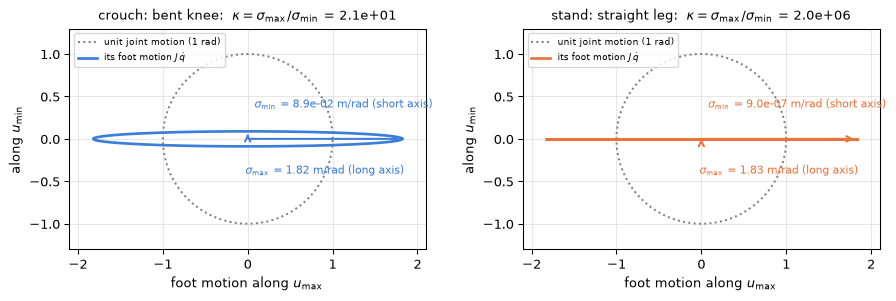

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.5))
t = np.linspace(0, 2 * np.pi, 400)
for ax, (name, Jp, col) in zip(axes, (("crouch: bent knee", J_crouch, "#3b7dd8"),
                                       ("stand: straight leg", J, "#e8743b"))):
    U, sig, Vt = np.linalg.svd(Jp)
    # every unit joint motion in the plane of the best and worst joint directions ...
    Q = np.outer(Vt[0], np.cos(t)) + np.outer(Vt[-1], np.sin(t))       # 6 x 400, |q| = 1
    X = Jp @ Q                                                          # ... and its foot motion
    a, b = U[:, 0] @ X, U[:, -1] @ X                                    # read along u_max, u_min
    ax.plot(np.cos(t), np.sin(t), ":", color="0.5", label="unit joint motion (1 rad)")
    ax.plot(a, b, lw=2, color=col, label=r"its foot motion $J\,\dot q$")
    ax.annotate("", (sig[0], 0), (0, 0), arrowprops=dict(arrowstyle="->", color=col, lw=1.5))
    ax.annotate("", (0, sig[-1]), (0, 0), arrowprops=dict(arrowstyle="->", color=col, lw=1.5))
    ax.text(sig[0] / 2, -0.42, r"$\sigma_{\max}$ = " + f"{sig[0]:.2f} m/rad (long axis)", ha="center", fontsize=8, color=col)
    ax.text(0.08, 0.36, r"$\sigma_{\min}$ = " + f"{sig[-1]:.1e} m/rad (short axis)", fontsize=8, color=col)
    ax.set_aspect("equal"); ax.set_xlim(-2.1, 2.1); ax.set_ylim(-1.3, 1.3)
    ax.set_title(name + r":  $\kappa = \sigma_{\max}/\sigma_{\min}$ = " + f"{sig[0] / sig[-1]:.1e}", fontsize=10)
    ax.set_xlabel(r"foot motion along $u_{\max}$"); ax.set_ylabel(r"along $u_{\min}$")
    ax.legend(fontsize=7, loc="upper left"); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

The dotted circle is every joint motion of one radian, taken in the
plane of the best and the worst joint directions; the coloured curve is
where $J$ sends it. <span style="color:#3b7dd8">Crouched</span>, the
ellipse is squashed about 20:1 — long along $u_{\max}$, short but
*there* along $u_{\min}$, so a request in the short direction costs 20
times more joint motion and is still answerable.
<span style="color:#e8743b">Standing</span>, the ellipse has collapsed
to a line: the axis that would shorten the leg is $10^{-6}$ long. A
straight leg has **no direction that shortens it**. The Jacobian has
lost a rank, undamped IK divides by nearly zero, and no amount of
iteration helps — the information simply is not there.

------------------------------------------------------------------------

## Six singular values, two poses

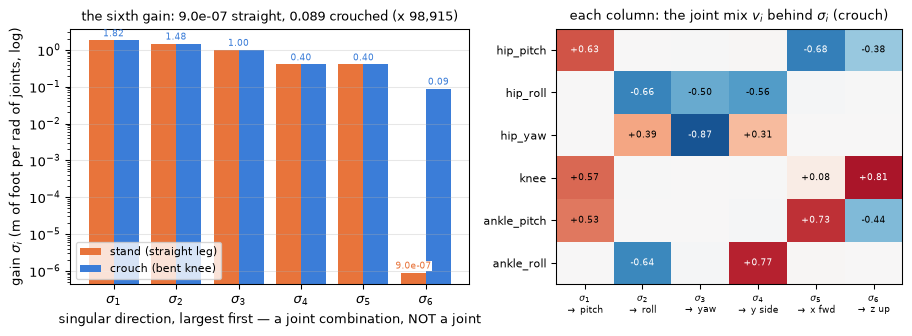

In [12]:
U, sig_c, Vt = np.linalg.svd(J_crouch)                  # crouch: U foot directions, Vt joint directions
foot = ["x fwd", "y side", "z up", "roll", "pitch", "yaw"]
joints = [mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, model.dof_jntid[d])
          .replace("left_", "").replace("_joint", "") for d in kin.leg_dof_indices(model, "left")]
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.6, 3.6), gridspec_kw={"width_ratios": [1.15, 1]})

x = np.arange(6)
ax0.bar(x - 0.2, sv, 0.4, color="#e8743b", label="stand (straight leg)")
ax0.bar(x + 0.2, sv_crouch, 0.4, color="#3b7dd8", label="crouch (bent knee)")
ax0.set_yscale("log"); ax0.set_xticks(x, [f"$\\sigma_{i + 1}$" for i in x])
ax0.set_xlabel("singular direction, largest first — a joint combination, NOT a joint")
ax0.set_ylabel("gain $\\sigma_i$ (m of foot per rad of joints, log)")
ax0.legend(fontsize=8, loc="lower left")
for xi, (a_, b_) in enumerate(zip(sv, sv_crouch)):   # the first five pairs agree; label them once
    ax0.annotate(f"{b_:.2f}", (xi + (0.2 if xi == 5 else 0), b_), xytext=(0, 3),
                 textcoords="offset points", ha="center", fontsize=7, color="#3b7dd8")
ax0.annotate(f"{sv[-1]:.1e}", (5 - 0.2, sv[-1]), xytext=(0, 3), textcoords="offset points", ha="center",
             fontsize=7, color="#e8743b", bbox=dict(fc="w", ec="none", pad=0.3), zorder=5)
ax0.set_title(f"the sixth gain: {sv[-1]:.1e} straight, {sv_crouch[-1]:.3f} crouched "
              f"(x {sv_crouch[-1] / sv[-1]:,.0f})", fontsize=10)
ax0.grid(axis="y", alpha=0.3)

# what each singular direction is made of: its joint combination v_i (a column),
# and the single foot direction u_i it moves (written under the column)
ax1.imshow(Vt.T, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax1.set_yticks(range(6), joints, fontsize=8)
ax1.set_xticks(range(6), [f"$\\sigma_{i + 1}$\n" + r"$\rightarrow$ " + foot[int(np.argmax(np.abs(U[:, i])))]
                          for i in range(6)], fontsize=7)
for i in range(6):                                       # direction i, joint j
    for j in range(6):
        v = Vt[i, j]
        if abs(v) > 0.05:
            ax1.text(i, j, f"{v:+.2f}", ha="center", va="center", fontsize=7, color="w" if abs(v) > 0.6 else "k")
ax1.set_title("each column: the joint mix $v_i$ behind $\\sigma_i$ (crouch)", fontsize=10)
fig.tight_layout(); plt.show()

**The x-axis is not a list of joints.** Each bar is one *singular
direction*: a joint combination $v_i$ — a column on the right, signs
relative within the column — that $J$ turns into one foot-space
direction $u_i$ (written under the column) with gain $\sigma_i$.
Directions are ordered by gain, largest first.

The sixth column is $-0.38\,$hip pitch $+\,0.81\,$knee $-\,0.44\,$ankle
pitch: bend the knee and pitch hip and ankle back so the foot stays
level — the one motion that *shortens the leg* — and it moves the foot
straight up or down ($u_6$ is pure $z$). The mix is the same in both
poses; only the gain changes. Crouched, that combination buys 0.089 m
per radian; straight, $9 \times 10^{-7}$ — a factor of a hundred
thousand, restored by bending the knee. That one number is why every
gait in the course starts from a crouch.

------------------------------------------------------------------------

## The consequence, measured

Ask the solver to lower the pelvis 8 cm, from each of two seeds:

In [13]:
scratch = mujoco.MjData(model)
sid = {s: kin.foot_site_id(model, s) for s in ("left", "right")}
feet = {s: (data.site_xpos[sid[s]].copy(), data.site_xmat[sid[s]].reshape(3, 3).copy())
        for s in ("left", "right")}
base = data.qpos[:3].copy() - [0, 0, 0.08]

straight = data.qpos.copy()                       # the 'stand' singularity
crouch = soc4180.WalkingController(model).nominal  # bent knees

for label, seed in (("straight-leg seed", straight), ("crouched seed", crouch)):
    r = kin.ik_legs(model, scratch, base, data.qpos[3:7], feet,
                    seed_qpos=seed, iterations=40)
    print(f"  {label:20s} residual error = {r['error']:.2e}   knee = {r['left'][3]:+.3f} rad")

  straight-leg seed    residual error = 7.89e-01   knee = -0.087 rad
  crouched seed        residual error = 2.23e-06   knee = +1.015 rad

**The same request, the same solver, a different starting pose — and one
of them simply cannot be solved.** This is why every gait in this course
starts from a crouch, and why humans do not walk with locked knees.

------------------------------------------------------------------------

## Reaching a target

With the crouch as a seed, IK is exact. Move the foot somewhere new:

In [14]:
target = feet["left"][0] + np.array([0.15, 0.0, 0.05])
r = kin.ik_legs(model, scratch, data.qpos[:3], data.qpos[3:7],
                {**feet, "left": (target, feet["left"][1])}, seed_qpos=crouch)

q = crouch.copy()
q[:3] = data.qpos[:3]; q[3:7] = data.qpos[3:7]
for s in ("left", "right"):
    q[kin.leg_qpos_indices(model, s)] = r[s]
achieved, _ = soc4180.fk_foot(model, q, "left")

print(f"requested : {np.round(target, 5)}")
print(f"achieved  : {np.round(achieved, 5)}")
print(f"error     : {np.linalg.norm(achieved - target):.2e} m")
print(f"joint angles: {np.round(r['left'], 3)}")

requested : [0.15    0.11851 0.08314]
achieved  : [0.15    0.11851 0.08314]
error     : 1.29e-16 m
joint angles: [-0.546  0.    -0.     0.629 -0.083  0.   ]

Checked with **last week’s** forward kinematics, not with the solver’s
own opinion of itself.

------------------------------------------------------------------------

## Trace a circle

The real test of a solver is a whole path, not one point. Kinematics
only — the robot is placed, never simulated:

In [15]:
poses = []
centre = feet["left"][0] + np.array([0.05, 0.0, 0.06])
errors = []
seed = crouch.copy()

for angle in np.linspace(0, 2 * np.pi, 90):
    goal = centre + np.array([0.09 * np.cos(angle), 0.0, 0.04 * np.sin(angle)])
    r = kin.ik_legs(model, scratch, data.qpos[:3], data.qpos[3:7],
                    {**feet, "left": (goal, feet["left"][1])}, seed_qpos=seed)
    q = seed.copy(); q[:3] = data.qpos[:3]; q[3:7] = data.qpos[3:7]
    for s in ("left", "right"):
        q[kin.leg_qpos_indices(model, s)] = r[s]
    seed = q                      # warm start from the previous solution
    poses.append(q.copy()); errors.append(r["error"])

print(f"90 targets, worst residual error = {max(errors):.2e} m")
frames = soc4180.render_poses(model, poses, width=560, height=460)
soc4180.show_video(frames, fps=30)

90 targets, worst residual error = 8.37e-05 m

------------------------------------------------------------------------

## Ask for one centimetre more

Stretch the circle vertically and the solver stops tracking — but only
in one place:

In [16]:
worst, where = 0.0, None
seed = crouch.copy()
for angle in np.linspace(0, 2 * np.pi, 90):
    goal = centre + np.array([0.09 * np.cos(angle), 0.0, 0.06 * np.sin(angle)])
    r = kin.ik_legs(model, scratch, data.qpos[:3], data.qpos[3:7],
                    {**feet, "left": (goal, feet["left"][1])},
                    seed_qpos=seed, iterations=120)
    q = seed.copy(); q[:3] = data.qpos[:3]; q[3:7] = data.qpos[3:7]
    for side in ("left", "right"):
        q[kin.leg_qpos_indices(model, side)] = r[side]
    seed = q
    if r["error"] > worst:
        worst, where = r["error"], np.degrees(angle)

print(f"worst residual {worst:.2e} m, at {where:.0f} degrees around the circle")

worst residual 2.68e-03 m, at 279 degrees around the circle

**120 iterations changes nothing** — the error is identical at 12. That
is the signature of a target that is *unreachable*, not one the solver
ran out of time on. At the bottom of the circle the foot is asked to go
below what the leg can reach with the pelvis where it is: the annulus
from the start of the lecture, met from the outside.

A residual that will not shrink with more iterations is a **geometry**
problem. Only a residual that shrinks slowly is a solver problem.

------------------------------------------------------------------------

## Why exactly there

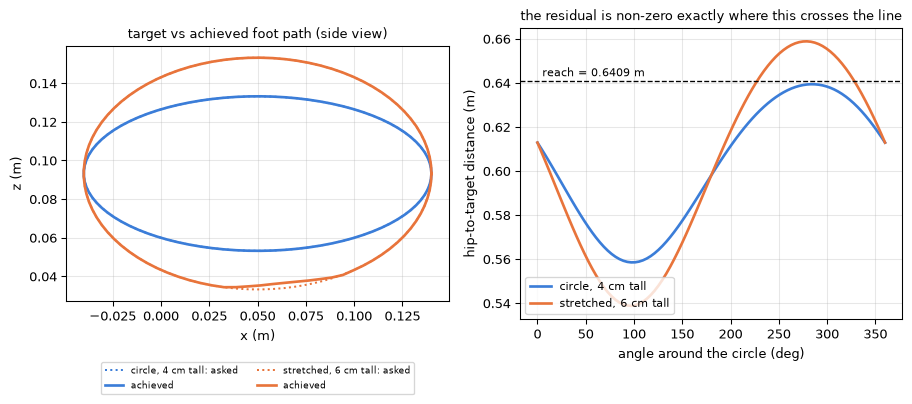

In [17]:
hip = anchor("left_hip_pitch_link")
angles = np.linspace(0, 2 * np.pi, 90)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.6, 4.0))
for rz, col, label in ((0.04, "#3b7dd8", "circle, 4 cm tall"),
                       (0.06, "#e8743b", "stretched, 6 cm tall")):
    seed = crouch.copy(); dist, tg, ach = [], [], []
    for angle in angles:
        goal = centre + np.array([0.09 * np.cos(angle), 0.0, rz * np.sin(angle)])
        r = kin.ik_legs(model, scratch, data.qpos[:3], data.qpos[3:7],
                        {**feet, "left": (goal, feet["left"][1])}, seed_qpos=seed)
        q = seed.copy(); q[:3] = data.qpos[:3]; q[3:7] = data.qpos[3:7]
        for side in ("left", "right"):
            q[kin.leg_qpos_indices(model, side)] = r[side]
        seed = q
        dist.append(np.linalg.norm(goal - hip))
        tg.append(goal); ach.append(soc4180.fk_foot(model, q, "left")[0])
    tg, ach = np.array(tg), np.array(ach)
    ax0.plot(tg[:, 0], tg[:, 2], ":", color=col, lw=1.5, label=f"{label}: asked")
    ax0.plot(ach[:, 0], ach[:, 2], "-", color=col, lw=2, label="achieved")
    ax1.plot(np.degrees(angles), dist, color=col, lw=2, label=label)
ax0.set_aspect("equal"); ax0.set_xlabel("x (m)"); ax0.set_ylabel("z (m)")
ax0.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2)
ax0.set_title("target vs achieved foot path (side view)", fontsize=10)
ax1.axhline(thigh + shin, color="k", ls="--", lw=1)
ax1.text(5, thigh + shin + 0.002, f"reach = {thigh + shin:.4f} m", fontsize=8)
ax1.set_xlabel("angle around the circle (deg)"); ax1.set_ylabel("hip-to-target distance (m)")
ax1.legend(fontsize=8, loc="lower left")
ax1.set_title("the residual is non-zero exactly where this crosses the line", fontsize=10)
for a in (ax0, ax1):
    a.grid(alpha=0.3)
fig.tight_layout(); plt.show()

For about 30° around the bottom of the stretched circle the
hip-to-target distance climbs **above the leg’s reach**, and that is
precisely where the achieved path flattens off the dotted target.
Everywhere else the two curves are indistinguishable at this scale.
Reachability is a property of the *target*, and you can check it with a
ruler before running any solver.

------------------------------------------------------------------------

## Two habits worth keeping

**Warm starting.** Each solve begins from the previous answer. It
converges in fewer iterations, and — more importantly — it picks the
solution *near* the last one, so the leg does not flip between
knee-forward and knee-back mid-path.

**Joint limits, every iteration.** The solver clamps after each step.
Without that, IK cheerfully returns a mathematically perfect pose that
the robot’s mechanical stops forbid.

Both matter next week, where this runs 500 times a second while the
robot is actually falling forwards.

------------------------------------------------------------------------

## What Week 4 does with this

You now have everything the walker needs:

| This week | Week 4 |
|----|----|
| Place a foot at a target | Place it on a planned footstep |
| Trace a path | Follow a swing trajectory |
| Pelvis given, legs solved | Pelvis follows the LIPM |
| Crouch to avoid singularity | Every gait starts crouched |
| Warm starting | 500 solves per second, each seeded by the last |

Next week the targets stop being ours to choose. They come from a
**balance model**, and the robot walks.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/03-inverse-kinematics/lab_ik.py
```

The G1 in the crouch, a **red** target you move with the arrow keys, a
**green** sphere at the foot, and a translucent sphere showing the leg’s
reach. Nothing is simulated; the pelvis never moves.

**The code is complete and explained.** Section 2 of the script is this
lecture in three functions — `dls_step`, `inverse_step`,
`transpose_step` — each commented against the slide it comes from; `M`
swaps them live. Section 4 explains what the script does around a
solver: `qpos` vs `qvel` indices, `mj_jacSite`, `pose_error`, the clip
to joint limits, `mj_forward`.

------------------------------------------------------------------------

## Lab class: the experiments

Eight experiments in the docstring, each with the numbers it should
produce, all measured with the script’s own functions before they were
written:

| \# | Do | Right looks like |
|------------------------|------------------------|------------------------|
| 1 | dls, up arrow ×5 | residual 4e-6 after one frame |
| 2 | `M` inverse, `S` straight leg, arrow down | $\|\Delta q\| = 10^4$ rad; the leg folds onto its joint limits |
| 3 | dls, straight leg, `]` to $\lambda = 0.1$ | $\|\Delta q\| = 10^{-4}$ and the foot never moves: no $\lambda$ helps |
| 4 | `M` transpose | creeps, never explodes |
| 5 | right arrow ×30 | hip distance \> reach; residual stops shrinking |
| 6 | `]` to $\lambda = 1$ | 3 cm of 5 left after a second: find the largest $\lambda$ that still tracks |
| 7 | `O`, `.` ×15 | the foot tilts 16° with 3 rows, levels with 6 |

Then break a solver on purpose (`-dq`; the transpose without its step
length) and explain what you see.

------------------------------------------------------------------------

## Exercises

1.  **Both elbows.** The knee has two solutions. Force the other one by
    seeding with a negative knee angle. Does the solver find it, and
    does the foot end up in the same place?
2.  **Out of reach.** Ask for a foot target 0.8 m from the hip. What
    does the residual error do, and what pose does the solver settle
    into?
3.  **Damping sweep.** Trace the circle with $\lambda = 0$ and
    $\lambda = 1$. Compare worst-case error against the largest single
    joint step.
4.  **No warm start.** Re-seed every solve from the crouch instead of
    the previous pose. Watch for discontinuities in the joint
    trajectories, and plot them.
5.  **Wrong anchor.** Feed IK a target orientation tilted 20° from flat.
    Is it reachable? What does that imply about walking on a slope?
6.  **Count the iterations.** Instrument `ik_legs` to report iterations
    used per solve along the circle. Where on the path is it working
    hardest, and why?

------------------------------------------------------------------------

## Next week

**04 — the robot walks.** Footstep planning, the linear inverted
pendulum, and the analytic gait that carries a 29-DOF humanoid across
the floor with no learning of any kind.

Bring the crouch.